In [1]:
import numpy as np
import torch
from torch.autograd import grad
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim.lr_scheduler import ExponentialLR
import numpy as np

# from pinnutils import *
from scipy.interpolate import griddata
from itertools import product, combinations
from scipy.io import savemat, loadmat
from torch.optim.lr_scheduler import ExponentialLR, MultiStepLR
from tqdm import tqdm_notebook as tqdm 
import torch.nn as nn
import torch.nn.functional as F
import math
import scipy.io as sio
import matplotlib.pyplot as plt
from pinnutils import *
from tqdm import tqdm_notebook as tqdm
from scipy.linalg import sqrtm
from chebyshev_utils import *
from GEOMLOSS import samples_loss

import matplotlib as mpl
import matplotlib.font_manager
fpaths = matplotlib.font_manager.findSystemFonts()
mpl.rcParams.update({# Use mathtext, not LaTeX
                            'text.usetex': False,
                            # Use the Computer modern font
                            'font.family': 'serif',
                            'font.serif': 'cmr10',
                            'mathtext.fontset': 'cm',
                            # Use ASCII minus
                            'axes.unicode_minus': False,
                            })
matplotlib.rcParams.update({'font.size': 16})
import seaborn as sns

2026-01-16 12:01:35.352824: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768582895.366721 1295769 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768582895.371051 1295769 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# x_ = np.linspace(0,3,50);
# y_ = np.linspace(0,3,50);
# xx_, yy_ = np.meshgrid(x_,y_);

# xtest = np.vstack([xx_.flatten(), yy_.flatten()]).T
# growth_ = ( 1.0*(xtest[:,1]**2)/(5+xtest[:,1]**2)  + 0.5*(xtest[:,0]**2)/(1+xtest[:,0]**2) )

# plt.imshow(growth_.reshape(50,50),origin='lower',vmin=0,vmax=0.75)
# plt.colorbar(pad=0.04, fraction=0.046)

### Simulate toggle_switch and generate data

In [4]:
def toggle_switch(x,model_params_):
    a1, a2, b1, b2, K1, K2, n = model_params_

    x_ = np.zeros_like(x)
    f = np.zeros_like(x);
    xn = x**n + 0;
    f[:,0] = (a1*(xn[:,0])/(K1**n + xn[:,0])) + b1*(K1**n)/(K1**n + xn[:,1]) # degration is always set to one
    f[:,1] = (a2*(xn[:,1])/(K2**n + xn[:,1])) + b2*(K2**n)/(K2**n + xn[:,0]) # degration is always set to one

    return f

def g_rate(x1,x2,gr):
    """Growth propensity based on gene2 expression."""
    return  gr*( 1.0*(x2**2)/(1+x2**2)  + 0.0*(x1**2)/(1+x1**2) )
    
#return  gr*( (x2**2) / (2 + x2**2)  ) #gr*( ((x2**2) / (1 + x2**2)) + ((x1**2) / (1 + x1**2)) )

def simulate_toggle_with_growth(nsamples, init, Nsnaps, Ndim, seed_, maxiter, model_params, vol, gr, growth_flag=False, reaction_flag=False):
    dt = 0.01; lx = 1
    np.random.seed(seed_)

    xold = init + 0.1*np.random.normal(0,1, (Ndim, nsamples)) #0*np.zeros((Ndim, nsamples))  # shape (Ndim, nsamples)
    tt = np.zeros(Nsnaps)
    samples_fullx = []  # will store a list of arrays with shape (n(t), Ndim)

    for snap in range(Nsnaps):
        steps = int(maxiter / Nsnaps)
        t_snap = snap * steps * dt
        tt[snap] = t_snap

        for _ in range(steps):
            if(reaction_flag):
                fval = toggle_switch(xold.T, model_params).T  # (Ndim, nsamples)
                noise = np.sqrt(fval + lx * xold) * np.sqrt(dt) * np.random.normal(0, 1, xold.shape)
                xnew = xold + dt * (fval - lx * xold) + (1 / np.sqrt(vol)) * noise

            # Reflect negatives
                xnew = np.where(xnew < 0, xold, xnew)
                xold = xnew + 0;
            else:
                fval = 0.01*toggle_switch(xold.T, model_params).T  # (Ndim, nsamples)
                noise = np.sqrt(fval + 0.1*lx * xold) * np.sqrt(dt) * np.random.normal(0, 1, xold.shape)
                xnew = xold + dt * (fval - 0.1*lx * xold) + (1 / np.sqrt(vol)) * noise

            # Reflect negatives
                xnew = np.where(xnew < 0, xold, xnew)
                xold = xnew + 0;

            if(growth_flag):
                x1 = xold[0]; x2 = xold[1];
                growth_probs = g_rate(x1, x2, gr) * dt
                divide_flags = np.random.rand(x2.shape[0]) < growth_probs
                new_cells = xold[:, divide_flags]  # shape: (Ndim, #dividing cells)

                if new_cells.shape[1] > 0:
                    xold = np.concatenate([xold, new_cells], axis=1)

        samples_fullx.append(xold.T.copy())

    return samples_fullx, tt

#### model_params = [a1, a2, b1, b2, K1, K2, n]
model_params = np.array([2., 2., 1.0, 1.0, 1.0, 1.0, 4.0])

Ndim = 2; vol = 4.0; nsamples = 2001; Nsnaps = 10; seed = 0; maxiter = 200; 

gr = 2.0; #growth-rate
growth_flag_ = True; # Set True if growth is modeled
reaction_flag_ = True; # Set True if the reaction is modeled 
init = np.random.uniform(0.25,0.75,(Ndim,nsamples)) + 0;
# init[0,:] = init[0,:] ;
samples_full, tt = simulate_toggle_with_growth(nsamples,init,Nsnaps,Ndim,seed,maxiter,model_params,vol,gr,\
                                               growth_flag=growth_flag_,reaction_flag=reaction_flag_);
samples_full = samples_full[:] 
nsnaps = len(samples_full); 
tt = tt[:]
dt = tt[1] - tt[0];
print(" physical-times of measurement ", tt, " dt ", dt, " nsnaps ", nsnaps)

 physical-times of measurement  [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8]  dt  0.2  nsnaps  10


In [5]:
np.random.uniform(0,1,(2,10)).shape

(2, 10)

### Tracking total-mass over time

In [6]:
mass_vec = np.ones((nsnaps,))
print(0, len(samples_full[0]))
for k in range(1,nsnaps):
    mass_vec[k] = len(samples_full[k])/len(samples_full[0])
    print(k, len(samples_full[k]))
mass_vec = torch.tensor(mass_vec,dtype=torch.float32,device=device)
print(" ground-truth mass ratio over time ", mass_vec)

0 2227
1 2559
2 2953
3 3522
4 4254
5 5261
6 6742
7 8683
8 11366
9 15028
 ground-truth mass ratio over time  tensor([1.0000, 1.1491, 1.3260, 1.5815, 1.9102, 2.3624, 3.0274, 3.8990, 5.1037,
        6.7481], device='cuda:0')


### Visualize mRNA count data

(2227, 2)
(2559, 2)
(2953, 2)
(3522, 2)
(4254, 2)
(5261, 2)
(6742, 2)
(8683, 2)
(11366, 2)
(15028, 2)


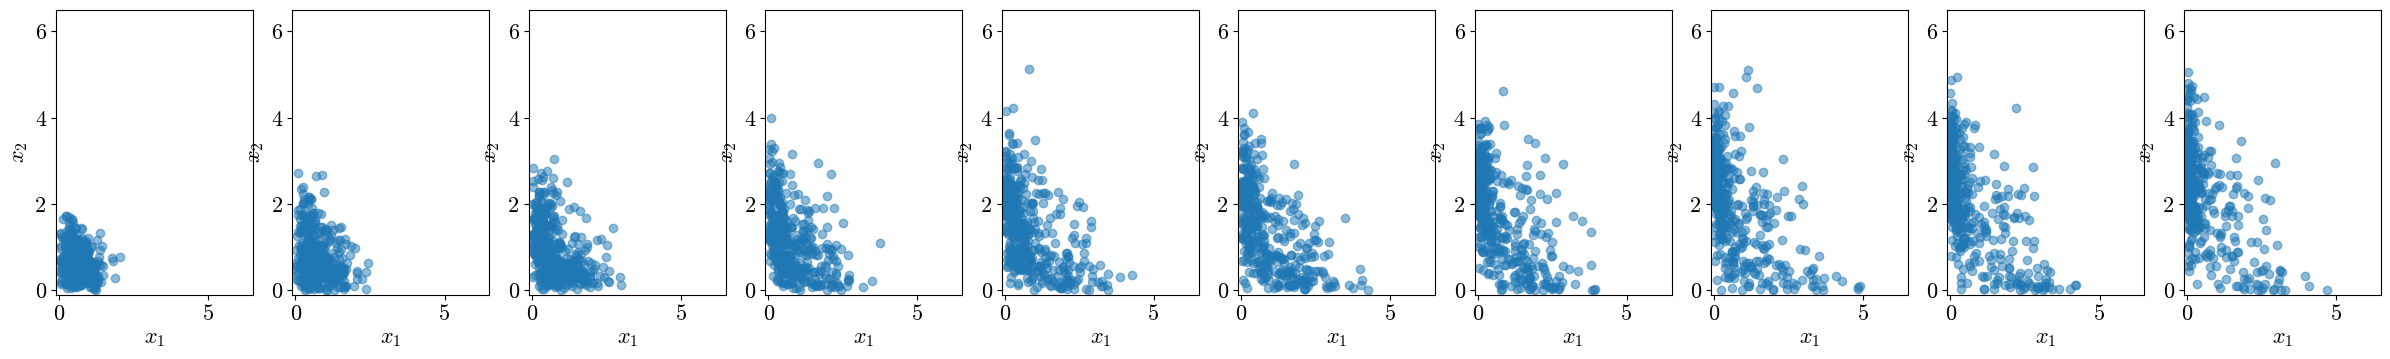

In [7]:
for k in range(0, len(samples_full)):
    plt.subplot(1,len(samples_full),k+1)
    print(samples_full[k].shape)
    ind_s = np.arange(0,samples_full[k].shape[0])
    np.random.shuffle(ind_s)
    plt.scatter(samples_full[k][ind_s[0:400],0],samples_full[k][ind_s[0:400],1],alpha=0.5)
    plt.xlim(-0.1,6.5); plt.ylim(-0.1,6.5)
    plt.xlabel(r'$x_1$'); plt.ylabel(r'$x_2$')
plt.gcf().set_size_inches(30,3.7)

## Sample data via MMOT

In [8]:
def samples_rep(samples_):
    nrep = 1;
    print(" # of repetitions ", nrep)
    nsamples_ = 2000; #
    
    ### shuffle data to de-correlate the data in time
    Dist_ = np.zeros((len(samples_),nrep,nsamples_,Ndim))   
    for k in range(0, len(samples_)):
        ind_s = np.arange(0,samples_[k].shape[0])
        for j in range(0, nrep):
            np.random.shuffle(ind_s)
            Dist_[k,j,:,:] = samples_[k][ind_s[0:nsamples_],0:Ndim]

    ### Trajectory sampling
    Dist = np.zeros((len(samples_),nrep*nsamples_,Ndim))
    batch_ot_samples  =  torch.tensor(np.zeros((len(samples_),nrep*nsamples_,Ndim)),dtype=torch.float32,device=device)
    for j in range(0, nrep):
        before_ot = torch.tensor(Dist_[:,j,:,0:Ndim],dtype=torch.float32)
        Dist[:,j*nsamples_:(j+1)*nsamples_,:] = Dist_[:,j,:,:]
        before_ot = torch.tensor(Dist[:,j*nsamples_:(j+1)*nsamples_,:],dtype=torch.float32)
        batch_ot_samples[:,j*nsamples_:(j+1)*nsamples_,:] = mmot_trajectories(before_ot,nsamples_,device); #stitch_ot_trajectories(before_ot).to(device)

    return Dist, batch_ot_samples
        
Dist, batch_ot_samples = samples_rep(samples_full) #batch_ot_samples
tp = tt + 0;
print(tp.shape, Dist.shape, tp)
print(Dist[:,10,-1],tp)

 # of repetitions  1
(10,) (10, 2000, 2) [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8]
[0.80521441 0.52762939 1.35317589 1.36331706 0.42212491 2.30937944
 2.5581652  4.32142776 1.26789937 2.33195072] [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8]


In [9]:
nsamples = Dist.shape[1] + 0;
print(" nsamples ", nsamples, Dist.shape)

 nsamples  2000 (10, 2000, 2)


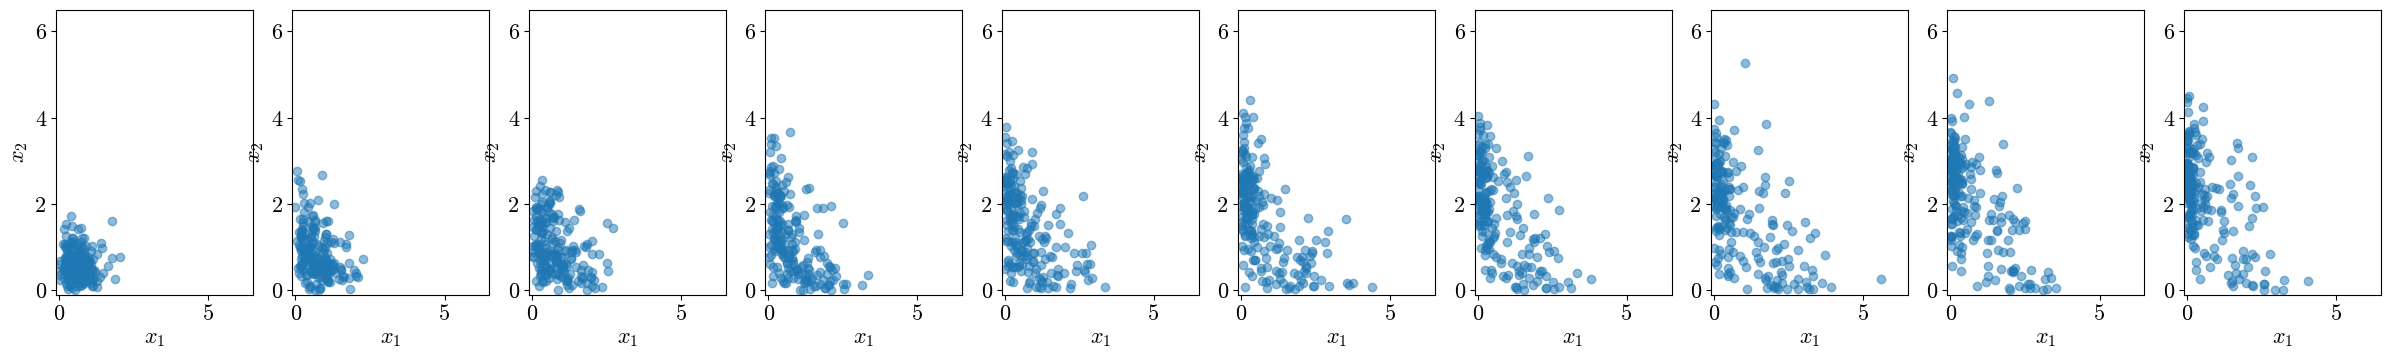

In [10]:
for k in range(0, Dist.shape[0]):
    plt.subplot(1,Dist.shape[0],k+1)
    plt.scatter(Dist[k,::10,0],Dist[k,::10,1],alpha=0.5)
    plt.xlim(-0.1,6.5); plt.ylim(-0.1,6.5)
    plt.xlabel(r'$x_1$'); plt.ylabel(r'$x_2$')
plt.gcf().set_size_inches(30,3.7)

## Validate the score-model by generating the data 

In [11]:
def setup_model(Ndim, mean, std, Np, seed_, spectral_flag=True):
    """
    Setup the encoder model and optimizer.
    """
    if(spectral_flag):
        print(" Applying Spectral-Norms ")
        encoder = SpectralNormDNN(
            sizes=[Ndim + 2, Np, Np, Np, Np, Np, Ndim],
            mean=mean.to(device), std=std.to(device),
            seed=seed_, activation=nn.ELU()
        ).to(device)
    else:
        print(" Vanilla DNN ")
        encoder = DNN(
            sizes=[Ndim + 2, Np, Np, Np, Np, Np, Ndim],
            mean=mean.to(device), std=std.to(device),
            seed=seed_, activation=nn.ELU()
        ).to(device)       
    
    print("#parameters:", sum(p.numel() for p in encoder.parameters() if p.requires_grad))
    return encoder, list(encoder.parameters())

Np = 50; spectral_flag = False; L = 10; n_epochs = 50_01; batch_size_score = nsamples + 0;
X_train, X_data, X_mean, X_std, sigma = generate_noisy_training_data_batch(Dist[:,0:nsamples,:], Ndim, tp, L, nsamples, nsnaps, device);
scoreNet, params = setup_model(Ndim, X_mean, X_std, Np, 0, spectral_flag);
start_time = time.time()
    
scoreNet = DSM_training_batched(Ndim, scoreNet, X_train, X_data, sigma, nsnaps, nsamples, L, adp_flag=1, n_epochs=n_epochs, bs=batch_size_score, device=device);

 done with time  0
 done with time  1
 done with time  2
 done with time  3
 done with time  4
 done with time  5
 done with time  6
 done with time  7
 done with time  8
 done with time  9
 X_train shape  torch.Size([10, 10, 2000, 4])
 X_data shape  torch.Size([10, 2000, 2])
 X-mean shape  torch.Size([1, 4])  X-std shape  torch.Size([1, 4])
 Vanilla DNN 
#parameters: 10552
cuda
 number of batches  1
 Xtrain device  cuda:0  Xdata device  cuda:0


  0%|          | 0/5001 [00:00<?, ?it/s]

epoch: 0 c_: tensor([0.0905, 0.0936, 0.0990, 0.1021, 0.1032, 0.1044, 0.1045, 0.1036, 0.1013,
        0.0979], device='cuda:0')
epoch: 250 c_: tensor([0.0224, 0.0394, 0.0823, 0.1666, 0.1723, 0.1213, 0.1127, 0.1174, 0.1168,
        0.0488], device='cuda:0')
epoch: 500 c_: tensor([0.0264, 0.0564, 0.1278, 0.1123, 0.1389, 0.1153, 0.1458, 0.1541, 0.0797,
        0.0433], device='cuda:0')
epoch: 750 c_: tensor([0.0316, 0.0673, 0.1753, 0.1089, 0.1134, 0.1007, 0.1375, 0.1546, 0.0666,
        0.0440], device='cuda:0')
epoch: 1000 c_: tensor([0.0334, 0.0718, 0.2242, 0.0991, 0.1038, 0.0947, 0.1431, 0.1376, 0.0566,
        0.0356], device='cuda:0')
epoch: 1250 c_: tensor([0.0312, 0.0730, 0.2486, 0.0803, 0.0979, 0.0977, 0.1388, 0.1478, 0.0498,
        0.0350], device='cuda:0')
epoch: 1500 c_: tensor([0.0269, 0.0677, 0.2307, 0.0692, 0.1011, 0.1171, 0.1357, 0.1597, 0.0494,
        0.0426], device='cuda:0')
epoch: 1750 c_: tensor([0.0236, 0.0587, 0.2572, 0.0636, 0.0971, 0.1291, 0.1425, 0.1333, 0.0468,


## Validate the score-model by generating the data

In [12]:
scoreNet = scoreNet.eval()

def validate_score(scoreNet,Ndim,nsnaps,Dist,L):
    nsamples = Dist.shape[1];
    loss = samples_loss.SamplesLoss("energy")
    eps = 5e-3; maxiter = 100; total_divergence = 0;
    for tinf in range(0,nsnaps):
        with torch.no_grad():
            infNet = scoreNet.eval()
            init_  = np.random.uniform(1.0,4.0,(nsamples,Ndim+2))  #
            init_[:,0:Ndim] = Dist[tinf,:,0:Ndim]
            print(" true mean ",np.mean(Dist[tinf,:,0:Ndim],axis=0)[0:Ndim])
            sol = generate_data_DSM(eps,maxiter,infNet,nsamples,init_,tp[tinf],L);
            divergence = loss(torch.tensor(sol[:,0:Ndim],dtype=torch.float32,device=device),torch.tensor(Dist[tinf,:,0:Ndim],dtype=torch.float32,device=device))
            print(" divergence for tinf ", tinf, " is ", divergence)
            total_divergence = divergence + total_divergence
            print(" \n ")
    print(" total-divergence ", total_divergence)
    return scoreNet

def generate_data_DSM(eps,maxiter,infNet,Nsamples,init_,time_,L):
    eps = 1e-4;
    sol = torch.tensor(init_,dtype=torch.float32).to(device)
    sol[:,Ndim+1] = time_
    sigma = geometric_sequence(L);
    for k in range(0,L):
        alpha = eps*((sigma[k]**2)/(sigma[L-1]**2))
        sol[:,Ndim] = sigma[k]
        for t in range(0,500):
            z = torch.normal(0, 1, size=(Nsamples, Ndim)).to(device)
            guru = infNet(sol) 
            sol[:,0:Ndim] = sol[:,0:Ndim] + 0.5*alpha*guru + np.sqrt(alpha)*z
    print(" final mean ",torch.mean(sol,axis=0)[0:Ndim])       
    sol = sol.cpu().data.numpy().reshape(Nsamples,Ndim+2)
    return sol

_ = validate_score(scoreNet,Ndim,nsnaps,Dist[:,:,0:Ndim],L);

 true mean  [0.61929452 0.63679804]
 final mean  tensor([0.6259, 0.7470], device='cuda:0')
 divergence for tinf  0  is  tensor(0.0089, device='cuda:0')
 
 
 true mean  [0.73658255 0.80806022]
 final mean  tensor([0.6858, 0.8169], device='cuda:0')
 divergence for tinf  1  is  tensor(0.0024, device='cuda:0')
 
 
 true mean  [0.81191827 0.97149521]
 final mean  tensor([0.8068, 0.8684], device='cuda:0')
 divergence for tinf  2  is  tensor(0.0057, device='cuda:0')
 
 
 true mean  [0.8669217 1.1669369]
 final mean  tensor([0.8497, 1.0064], device='cuda:0')
 divergence for tinf  3  is  tensor(0.0122, device='cuda:0')
 
 
 true mean  [0.87481837 1.34636622]
 final mean  tensor([0.8789, 1.2052], device='cuda:0')
 divergence for tinf  4  is  tensor(0.0088, device='cuda:0')
 
 
 true mean  [0.85645575 1.52358275]
 final mean  tensor([0.8997, 1.4486], device='cuda:0')
 divergence for tinf  5  is  tensor(0.0035, device='cuda:0')
 
 
 true mean  [0.7946251  1.76025354]
 final mean  tensor([0.8597, 1

In [13]:
def compute_conditional_distributions_chebyshev_with_growth(Dist, batch_size, mass_, nodes_fit, nodes_eval, reg_, sigma, err_flag=False,device='cuda'):
    """
    Compute conditional distributions using Chebyshev polynomial interpolation.

    Parameters:
    - Dist: Tensor of shape [T, nsamples, Ndim], time × samples × dimensions
    - batch_size: Number of trajectories to sample
    - nodes_fit: Tensor of shape [B, T1], time points for fitting (can vary per batch)
    - nodes_eval: Tensor of shape [B, T2], time points for evaluation (can vary per batch)
    - reg_: Regularization strength for Chebyshev interpolation
    - sigma: Standard deviation of Gaussian noise to add to inputs
    - ot: (Optional) flag for using optimal transport logic (unused here)

    Returns:
    - Xtrain: [batch_size * T2, Ndim + 2], inputs for training with noise and time appended
    - ytrain: [batch_size * T2, Ndim], interpolated derivatives
    - err: Relative interpolation error
    """

    nsamples = Dist.shape[1]
    Np = nodes_eval.shape[1]
    Ndim = Dist.shape[2]
    err = 0;

    # Initialize output tensors
    Xtrain = torch.zeros((batch_size * Np, Ndim + 2), dtype=torch.float32, device=device)
    ytrain = torch.zeros((batch_size * Np, Ndim), dtype=torch.float32, device=device)
    #mass_weight = torch.zeros((batch_size * Np), dtype=torch.float32, device=device)

    # Select batch of trajectories at random
    xind = torch.randint(0, nsamples, (batch_size,))
    Dist = torch.tensor(Dist, dtype=torch.float32, device=device)

    mass_weight = torch.permute(mass_[:,xind],(1,0))

    # Permute and extract [B, T, Ndim]
    x = torch.permute(Dist[:, xind, 0:Ndim], (1, 0, 2))

    # Fit Chebyshev polynomial interpolants
    coeffs, P, P_prime, (a, b) = batched_chebyshev_interpolate(
        nodes_fit, x, degree = nodes_fit.shape[1] - 1, lambda_reg=reg_, penalty='curvature'
    ) # always fitting polynomial of degree n-1.

    # Evaluate polynomial and derivative
    x_interp = P(nodes_eval)        # [B, T2, Ndim]
    dx_interp = P_prime(nodes_eval) # [B, T2, Ndim]

    # Compute interpolation error (relative MSE)
    if(err_flag):
        err = torch.mean((x_interp - x) ** 2) / torch.mean(x ** 2)

    # Construct training set
    Xtrain[:, Ndim] = 0.01
    Xtrain[:, Ndim + 1] = nodes_eval.view(batch_size * Np)

    mut = x_interp.view(batch_size * Np, Ndim)
    Xtrain[:, 0:Ndim] = mut + sigma * torch.randn_like(mut)
    ytrain[:, 0:Ndim] = dx_interp.view(batch_size * Np, Ndim)
    
    return Xtrain, ytrain, mass_weight

In [14]:
fac = 1
uniform_kind = torch.tensor(np.linspace(tp[0],tp[-1],fac*tp.shape[0]))
print(" data nodes ", tp)

data_nodes = torch.tensor(tp,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)
uniform_nodes = torch.tensor(uniform_kind,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)

batch_ot_samples_uniform = interpolate_old2new(batch_ot_samples, data_nodes, uniform_nodes).to(device);

batch_size = int(nsamples/4) + 0; # #batch_ot_samples.shape[1] #*nsamples;
uniform_batch = uniform_kind.expand(batch_size,-1).to(device)

print(" shape of nodes ",  uniform_batch.shape, batch_ot_samples_uniform.shape)

 data nodes  [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8]
 shape of nodes  torch.Size([500, 10]) torch.Size([10, 2000, 2])


### Estimating regularization strength for chebyshev interpolants

In [15]:
data_full = torch.tensor(tp,dtype=torch.float32).expand(batch_ot_samples.shape[1],-1).to(device)
data_highres = uniform_kind.expand(batch_ot_samples.shape[1],-1).to(device)
best_lam,_,_,_ = select_best_lambda(batch_ot_samples, batch_ot_samples.shape[1], data_full, data_full, Ndim, device);
print(" best_lam ", best_lam)

[λ-selection] Initial error: 1.1754
[λ-selection] Best λ (≥80% drop): 0.0010
[λ-selection] Test errors: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[λ-selection] Vel magnitudes: [1.17544055 0.86133671 0.7906335  0.74333531 0.6641714  0.65041667
 0.62683374 0.59736651 0.54870975 0.51228321 0.486285   0.46355417
 0.39079276 0.36151162]
 best_lam  0.001


In [16]:
X_mean = torch.zeros((Ndim,)); X_std = torch.ones((Ndim,))
for i in range(Ndim):
    X_mean[i] = torch.tensor(torch.mean(batch_ot_samples_uniform[:,:,i]).flatten(), dtype=torch.float32)
    X_std[i]  = torch.tensor(torch.std(batch_ot_samples_uniform[:,:,i]).flatten(), dtype=torch.float32)
X_mean = X_mean[np.newaxis,:]; X_std = X_std[np.newaxis,:]
print(" X-mean shape ", X_mean.shape, " X-std shape ", X_std.shape)

 X-mean shape  torch.Size([1, 2])  X-std shape  torch.Size([1, 2])


In [17]:
batch_size

500

In [18]:
def div_neural(drift,inp_,Ndim,inf_lx):
    jac = torch.zeros((drift.shape[0], Ndim, Ndim),device=device)
    div = drift.clone() + 0;
    for i in range(0, Ndim):
        out_ = drift[:,i]
        gradient = grad(outputs=out_, inputs=inp_,
                      grad_outputs=torch.ones_like(out_), 
                      create_graph=True)[0]
        jac[:,i,:] = gradient[:,0:Ndim].clone();
        div[:,i] = inf_lx + gradient[:,i].clone() + 0;
    
    return jac, div

## Flow-matching with growth

In [19]:
seed_ = 0;  lam = 1e-4; lx = 1;

growth_net = DNN(sizes=[Ndim, 25, 25, 25, 25, 1], seed=seed_, activation=nn.ELU()).to(device)
drift_net = DNN(sizes=[Ndim,25,25,25,25, Ndim], seed=seed_, activation=nn.ELU()).to(device)

print("#parameters:", sum(p.numel() for p in drift_net.parameters() if p.requires_grad) +
                     sum(p.numel() for p in growth_net.parameters() if p.requires_grad))
params_FM = [{'params': drift_net.parameters(), 'lr': 1e-3},
             {'params': growth_net.parameters(), 'lr': 1e-3}]

# Optimizer and scheduler
optimizer_FM = torch.optim.Adam(params_FM)
criterion = nn.MSELoss()
milestones_FM = [[1_000,1500,8_000,15000]]
scheduler_FM = MultiStepLR(optimizer_FM, milestones_FM[0], gamma=0.1)

start_time = time.time();
n_epochs = 2000; lamb = 1.0; alpha_ann = 0.5;
for epoch in range(n_epochs):
    optimizer_FM.zero_grad()

    # Infer growth and compute mass via trapezoidal rule
    growth_ = growth_net(batch_ot_samples_uniform).squeeze(-1)  # shape: (nsnaps, B)
    log_mass = torch.zeros_like(growth_)
    log_mass[0] = np.log(1. / batch_ot_samples_uniform.shape[1])
    for k in range(1, fac*nsnaps):
        log_mass[k] = log_mass[k - 1] + 0.5 * (dt/fac) * (growth_[k] + growth_[k - 1])
    mass_ = torch.exp(log_mass)
    pred_mass = torch.sum(mass_,axis=1)
    
    Xtrain, ytrain, weights_  = compute_conditional_distributions_chebyshev_with_growth(batch_ot_samples_uniform, batch_size, mass_,
                                                                                       uniform_batch, uniform_batch, reg_=best_lam, sigma=0.001, err_flag=False, device=device);
    # Xtrain, ytrain, _ = compute_conditional_distributions_chebyshev(batch_ot_samples_uniform, batch_size, 
    #                                                                                      uniform_batch, uniform_batch, reg_=best_lam, sigma=0.001, err_flag=False, device=device);

    # growth_ = growth_net(Xtrain[:,0:Ndim]).squeeze(-1).reshape(batch_size,fac*nsnaps)  # shape: (nsnaps, B)
    # log_mass = torch.zeros_like(growth_)
    # log_mass[:,0] = np.log(1. / batch_ot_samples_uniform.shape[1])

    # #print(" growth q ", log_mass[0].shape, growth_[0].shape)
    # for k in range(1, fac*nsnaps):
    #     log_mass[:,k] = log_mass[:,k - 1] + 0.5 * (dt/fac) * (growth_[:,k] + growth_[:,k - 1])
    # mass_ = torch.exp(log_mass)
    # weights_ = mass_ + 0;
    # pred_mass = torch.sum(mass_,axis=0)
    
    inp_  = Xtrain[:,0:Ndim].clone()
    inp_.requires_grad_()
    drift = drift_net(inp_) + 0;
    jac_d, div_d = div_neural(drift,inp_,Ndim,lx); 
    fold  = (drift - lx*Xtrain[:,0:Ndim]) - (0.5/vol)*div_d - (0.5/vol)*(drift + lx*Xtrain[:,0:Ndim])*scoreNet(Xtrain[:,:]) 
    
    if(epoch%200==0):
        print(" inferred mass" , torch.sum(mass_,axis=0)[::fac], mass_vec)
        print(" actual mass ",  mass_vec)    
    res = (fold - ytrain).pow(2).sum(dim=1).reshape(batch_size, fac*nsnaps)
    
    weights_ = weights_/torch.sum(weights_,axis=0)[None,:]

    test1 = torch.mean( weights_*res, axis=0 ) 
    #test1 = torch.mean( res, axis=0 ) 
    test2 = ((pred_mass[::fac] - mass_vec)**2)

    l1 = torch.sum(test1); 
    l2 = torch.sum(test2);
    
    if(epoch%10==0):
        with torch.no_grad():
            std_l1 = loss_grad_std(l1, drift_net, device)
            std_l2 = loss_grad_std(l2, growth_net, device) 
            lamb_hat = std_l1/std_l2;
            lamb     = (1-alpha_ann)*lamb + alpha_ann*lamb_hat

    total_loss =  l1 + lamb*l2

    if(epoch==0): print(" shapes ", Xtrain.shape,ytrain.shape)

    total_loss.backward() 
    optimizer_FM.step()
    scheduler_FM.step()
    
    if(epoch%200==0):
        print("epoch {}/{}, loss={:.10f},lr={:,.5f} lam={:,.5f}, \t\t\t".format(epoch+1, n_epochs, total_loss.item(), optimizer_FM.param_groups[0]['lr'], lamb), end="\r")  
        print(optimizer_FM.param_groups[0]['lr'])
        
print(" total-time taken ", time.time() - start_time)

#parameters: 4128
 inferred mass tensor([0.0052, 0.0053, 0.0051,  ..., 0.0052, 0.0042, 0.0049], device='cuda:0',
       grad_fn=<SliceBackward0>) tensor([1.0000, 1.1491, 1.3260, 1.5815, 1.9102, 2.3624, 3.0274, 3.8990, 5.1037,
        6.7481], device='cuda:0')
 actual mass  tensor([1.0000, 1.1491, 1.3260, 1.5815, 1.9102, 2.3624, 3.0274, 3.8990, 5.1037,
        6.7481], device='cuda:0')
 shapes  torch.Size([5000, 4]) torch.Size([5000, 2])
0.001 1/2000, loss=33.3816375732,lr=0.00100 lam=0.50116, 			
 inferred mass tensor([0.0259, 0.0108, 0.0121,  ..., 0.0131, 0.0070, 0.0072], device='cuda:0',
       grad_fn=<SliceBackward0>) tensor([1.0000, 1.1491, 1.3260, 1.5815, 1.9102, 2.3624, 3.0274, 3.8990, 5.1037,
        6.7481], device='cuda:0')
 actual mass  tensor([1.0000, 1.1491, 1.3260, 1.5815, 1.9102, 2.3624, 3.0274, 3.8990, 5.1037,
        6.7481], device='cuda:0')
0.001 201/2000, loss=0.0201259665,lr=0.00100 lam=0.00014, 			
 inferred mass tensor([0.0260, 0.0109, 0.0120,  ..., 0.0131, 0.006

In [20]:
vol, model_params, gr, batch_size

(4.0, array([2., 2., 1., 1., 1., 1., 4.]), 2.0, 500)

In [21]:
batch_ot_samples_uniform.shape, samples.shape

print(batch_ot_samples_uniform[5,1333,:], samples[5,1333,:])

NameError: name 'samples' is not defined

## Validation of the inferred force and growth model

 RMSE  0.14207564
 RMSE  0.061988942
 RMSE  0.038382012
 RMSE  0.027656296
 RMSE  0.02556661
 total err  0.02956695035099983


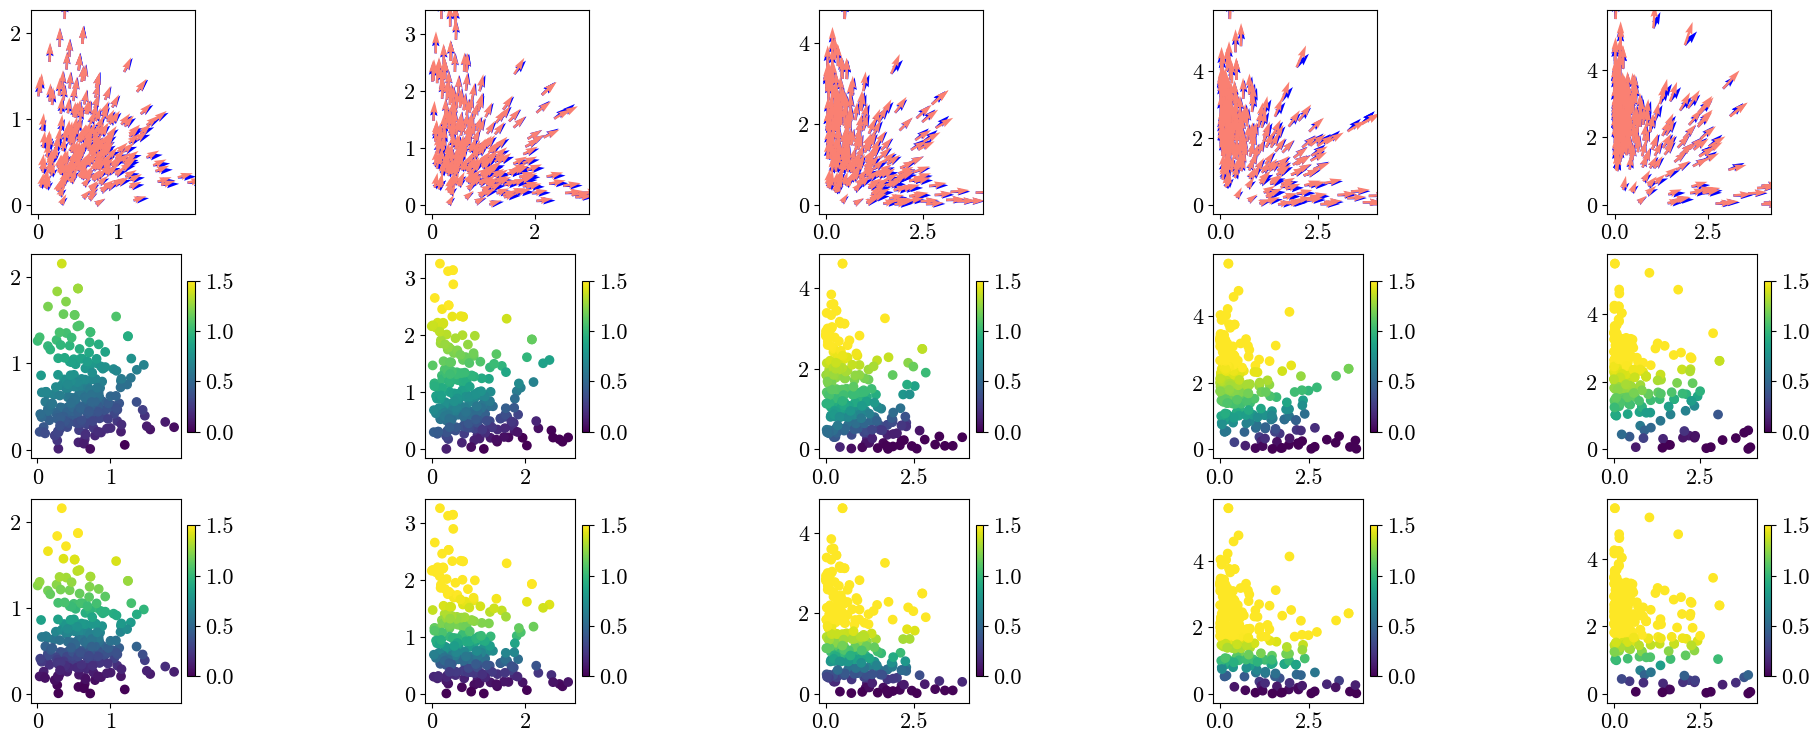

In [22]:
def drift_analytical(x,model_params_):

    a1,a2,b1,b2,K1,K2,n = model_params_
    
    force = np.zeros_like(x);
    x1n = x[:,0]**n; x2n = x[:,1]**n
    force[:,0] = (a1*x1n/((K1**n) + x1n)) + (b1*(K1**n)/((K1**n) + x2n));
    force[:,1] = (a2*x2n/((K2**n) + x2n)) + (b2*(K2**n)/((K2**n) + x1n));
    return force
    
growth_net.eval()
growth_inf = growth_net(batch_ot_samples_uniform).squeeze(-1)  # shape: (nsnaps, B)
growth_ = gr*((batch_ot_samples_uniform[:,:,1]**2)/(1+batch_ot_samples_uniform[:,:,1]**2) + 0.0*(batch_ot_samples_uniform[:,:,0]**2)/(1+batch_ot_samples_uniform[:,:,0]**2)  )
#growth_ = gr*( (batch_ot_samples_uniform[:,:,1]**2)/(1 + batch_ot_samples_uniform[:,:,1]**2) ) #( 1.0*(xtest[:,1]**2)/(2+xtest[:,1]**2)  + 0.25*(xtest[:,0]**2)/(1+xtest[:,0]**2) )

log_mass = torch.zeros_like(growth_)
log_mass[0] = np.log(1. / nsamples)
for k in range(1, nsnaps):
    log_mass[k] = log_mass[k - 1] + 0.5 * dt * (growth_[k] + growth_[k - 1])
mass_ = torch.exp(log_mass)

res = 8;
total_err = 0;
samples = batch_ot_samples_uniform.cpu().data.numpy() + 0; #np.asarray(samples_full)
for k in range(0,tp.shape[0],2):
    xtest = torch.tensor(samples[k,:,0:Ndim], dtype=torch.float32, device=device)
    force  = drift_analytical(xtest.cpu().data.numpy(),model_params) 
    drift  = drift_net(xtest).cpu().data.numpy()

    print(" RMSE ", np.mean(( (force - drift)**2 ).flatten())/np.mean( (force**2).flatten() )  )
    total_err = total_err + np.mean(( (force - drift)**2 ).flatten())/np.mean( (force**2).flatten() )
    
    plt.subplot(3,tp.shape[0],k+1)
    plt.quiver(samples[k,::res,0], samples[k,::res,1], force[::res,0], force[::res,1],scale=25,width=0.015,alpha=1.0,color='blue')
    plt.quiver(samples[k,::res,0], samples[k,::res,1], drift[::res,0], drift[::res,1],scale=25,width=0.015,alpha=1.0,color='salmon')

    plt.subplot(3,tp.shape[0],tp.shape[0]+k+1)
    plt.scatter(samples[k,::res,0], samples[k,::res,1], c = growth_inf[k,::res].cpu().data.numpy(),vmin=0,vmax=1.5)
    plt.colorbar(pad=0.04, fraction=0.046)

    plt.subplot(3,tp.shape[0],2*tp.shape[0]+k+1)
    plt.scatter(samples[k,::res,0], samples[k,::res,1], c = growth_[k,::res].cpu().data.numpy(),vmin=0,vmax=1.5)
    plt.colorbar(pad=0.04, fraction=0.046)
    #plt.quiver(samples[k,::res,0], samples[k,::res,1], drift[::res,0], drift[::res,1],scale=25,width=0.015,alpha=1.0,color='salmon')
print(" total err ", total_err/tp.shape[0])
# plt.tight_layout()
plt.gcf().set_size_inches(25,9)

(2500,) (2500,)
(2500, 2)
 RMSE  0.05283736782033396


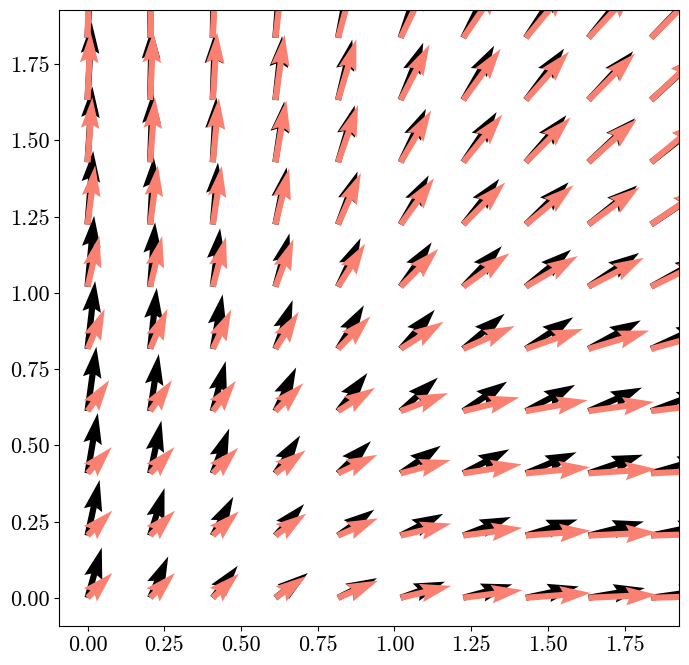

In [23]:
x_ = np.linspace(0,2,50);
y_ = np.linspace(0,2,50);
xx_, yy_ = np.meshgrid(x_,y_);

print(xx_.flatten().shape, np.ones((2500,)).shape)

xtest = np.vstack([xx_.flatten(), yy_.flatten(), np.ones((2500,))]).T

force  = drift_analytical(xtest[:,0:Ndim],model_params) 

xtest = torch.tensor(xtest[:,0:Ndim] , dtype=torch.float32, device=device)
drift  = drift_net(xtest).cpu().data.numpy()
print(drift.shape)

print(" RMSE ", np.mean(( (force - drift)**2 ).flatten())/np.mean( (force**2).flatten() )  )

res = 5;
plt.quiver(xx_[::res,::res],yy_[::res,::res],drift[::,0].reshape(50,50)[::res,::res],drift[::,1].reshape(50,50)[::res,::res],width=0.01,scale=25)
plt.quiver(xx_[::res,::res],yy_[::res,::res],force[::,0].reshape(50,50)[::res,::res],force[::,1].reshape(50,50)[::res,::res],color='salmon',width=0.01,scale=25)
plt.gcf().set_size_inches(8,8)

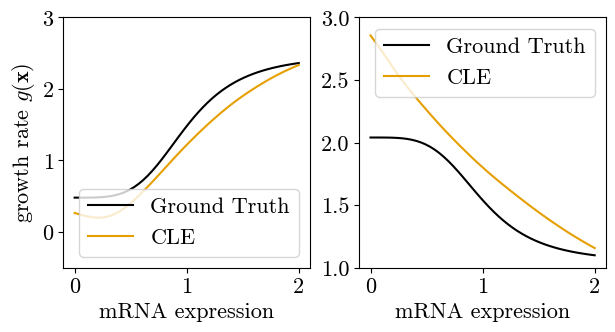

In [24]:
plt.subplot(1,2,1)
plt.plot(y_, force[:,0].reshape(50,50)[25,:],color='black',label='Ground Truth')
plt.plot(y_, drift[:,0].reshape(50,50)[25,:],color='#E69F00',label='CLE')
plt.xlabel('mRNA expression'); plt.ylabel(r'growth rate $g(\mathbf{x})$')
plt.legend(loc='best')
plt.ylim(-0.5,3)
plt.gcf().set_size_inches(7,3)

plt.subplot(1,2,2)
plt.plot(y_, force[:,1].reshape(50,50)[25,:],color='black',label='Ground Truth')
plt.plot(y_, drift[:,1].reshape(50,50)[25,:],color='#E69F00',label='CLE')
plt.xlabel('mRNA expression'); #plt.ylabel(r'growth rate $g(\mathbf{x})$')
plt.legend(loc='best')
plt.ylim(1,3)
plt.gcf().set_size_inches(7,3.25)


plt.savefig('results/CLE_force.svg')

In [25]:
model_params

array([2., 2., 1., 1., 1., 1., 4.])

torch.Size([10, 2000]) torch.Size([10, 2000])
 rmse of growth  tensor(0.0321, device='cuda:0', grad_fn=<DivBackward0>)


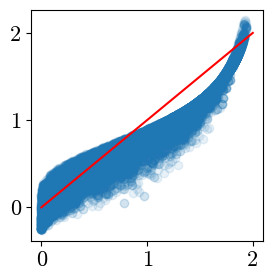

In [26]:
print(growth_.shape, growth_inf.shape)

plt.scatter(growth_.flatten().cpu().data.numpy(), growth_inf.flatten().cpu().data.numpy(),alpha=0.1)
plt.plot(np.linspace(0,2,10), np.linspace(0,2,10),color='red')
plt.gcf().set_size_inches(3,3)

rmse_growth = torch.mean((growth_ - growth_inf).flatten()**2)/torch.mean(growth_.flatten()**2)
print(" rmse of growth ", rmse_growth)

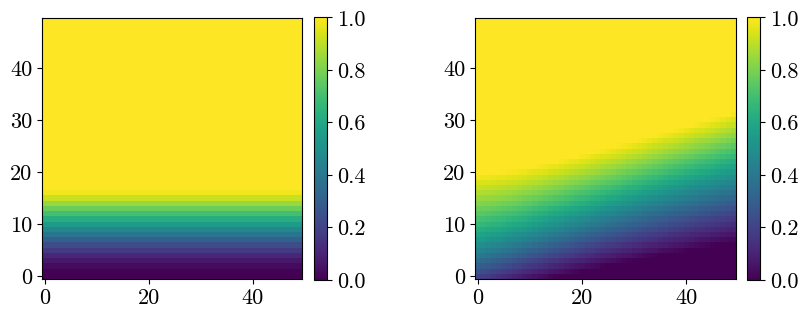

In [27]:
x_ = np.linspace(0,3,50);
y_ = np.linspace(0,3,50);
xx_, yy_ = np.meshgrid(x_,y_);

xtest = np.vstack([xx_.flatten(), yy_.flatten()]).T
growth_ = gr*( 1.0*(xtest[:,1]**2)/(1+xtest[:,1]**2)  + 0.0*(xtest[:,0]**2)/(1+xtest[:,0]**2) )

plt.subplot(1,2,1)
plt.imshow(growth_.reshape(50,50),origin='lower',vmin=0,vmax=1)
plt.colorbar(pad=0.04, fraction=0.046)

plt.subplot(1,2,2)
xtest_torch = torch.tensor(xtest,dtype=torch.float32).to(device)
growth_inf = growth_net(xtest_torch).squeeze(-1).cpu().data.numpy()
plt.imshow(growth_inf.reshape(50,50),origin='lower',vmin=0,vmax=1)
plt.colorbar(pad=0.04, fraction=0.046)

plt.tight_layout()
plt.gcf().set_size_inches(9,4)

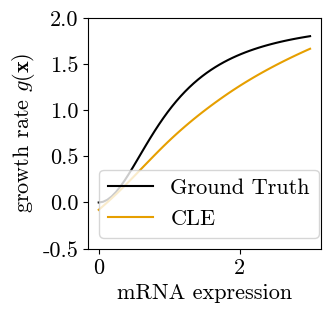

In [28]:
plt.plot(y_, growth_.reshape(50,50)[:,25],color='black',label='Ground Truth')
plt.plot(y_, growth_inf.reshape(50,50)[:,25],color='#E69F00',label='CLE')
plt.xlabel('mRNA expression'); plt.ylabel(r'growth rate $g(\mathbf{x})$')
plt.legend(loc='best')
plt.ylim(-0.5,2)
plt.gcf().set_size_inches(3,3)
plt.savefig('results/CLE_growth.svg')

In [30]:
res = 1; sim_dt = 0.01
total_err = 0;

test_init = np.random.uniform(0.25,0.4,(nsamples,2)) #Dist[0,:,0:Ndim] + 0; ##
#test_init[:,0:Ndim] = Dist[0,:,0:Ndim] + 0*0.5; #
test_init[:,0] = test_init[:,0] + 0.0;

#test_init = np.random.uniform(0.25,0.75,(nsamples,2)) #Dist[0,:,0:Ndim] + 0; ##
xtest_true = torch.tensor(test_init, dtype=torch.float32, device=device) #torch.tensor(samples[0,:,0:Ndim], dtype=torch.float32, device=device)
xtest_inf  = torch.tensor(test_init, dtype=torch.float32, device=device) #torch.tensor(samples[0,:,0:Ndim], dtype=torch.float32, device=device)
xtest_inf_ng  = torch.tensor(test_init, dtype=torch.float32, device=device) #torch.tensor(samples[0,:,0:Ndim], dtype=torch.float32, device=device)
for k in range(0,1000):
    
    drift  = drift_net(xtest_inf)
    noise_inf = torch.sqrt(drift + xtest_inf) * np.sqrt(sim_dt) * torch.randn_like(xtest_inf)
    xtest_inf_new = xtest_inf + sim_dt*(drift - xtest_inf) + 1.*(1 / np.sqrt(vol)) * noise_inf
    
    xtest_inf_new = torch.where(xtest_inf_new < 0, xtest_inf, xtest_inf_new)
    xtest_inf = xtest_inf_new + 0;

    drift_ng  = drift_net_ng(xtest_inf_ng)
    noise_inf_ng = torch.sqrt(drift_ng + xtest_inf_ng) * np.sqrt(sim_dt) * torch.randn_like(xtest_inf_ng)
    xtest_inf_new_ng = xtest_inf_ng + sim_dt*(drift_ng - xtest_inf_ng) + 1.*(1 / np.sqrt(vol)) * noise_inf_ng
    
    xtest_inf_new_ng = torch.where(xtest_inf_new_ng < 0, xtest_inf_ng, xtest_inf_new_ng)
    xtest_inf_ng = xtest_inf_new_ng + 0;
    
    force  = torch.tensor(drift_analytical(xtest_true.cpu().data.numpy(),model_params),dtype=torch.float32).to(device)
    noise_true = torch.sqrt(force + xtest_true) * np.sqrt(sim_dt) * torch.randn_like(xtest_true)
    xtest_true_new = xtest_true + sim_dt*(force - xtest_true)+ 1.*(1 / np.sqrt(vol)) * noise_true

    xtest_true_new = torch.where(xtest_true_new < 0, xtest_true, xtest_true_new)
    xtest_true = xtest_true_new + 0;

xtest_true = xtest_true.cpu().data.numpy() + 0;
xtest_inf = xtest_inf.cpu().data.numpy() + 0;
xtest_inf_ng = xtest_inf_ng.cpu().data.numpy() + 0;
    
# plt.gcf().set_size_inches(30,7)

NameError: name 'drift_net_ng' is not defined

In [ ]:
plt.subplot(1,2,1)
#plt.scatter(xtest_true[::1,0],xtest_true[::1,1],alpha=0.1)

sns.kdeplot(
    x=xtest_true[::1,0],
    y=xtest_true[::1,1],
    fill=True,
    cmap="Greys",
    levels=20,
    thresh=0.000,
    alpha=0.8
)
plt.xlabel("x")
plt.ylabel("y")
plt.scatter(xtest_inf[::4,0],xtest_inf[::4,1],alpha=1,color='red',edgecolor='black',s=50,label='Prediction')
plt.scatter(xtest_inf_ng[::4,0],xtest_inf_ng[::4,1],alpha=1,color='green',edgecolor='black',s=50,label='Prediction')
plt.scatter(xtest_true[::4,0],xtest_true[::4,1],alpha=1,color='royalblue',edgecolor='black',s=50,label='Prediction')
#plt.scatter(test_init[::50,0],test_init[::50,1],alpha=1,color='red',edgecolor='black',s=50,label='Initial condition')

#plt.scatter(xtest_inf[:,0],xtest_inf[:,1],alpha=0.1,color='red')
plt.xlim(0,5); plt.ylim(0,5)
plt.subplot(1,2,2)
#plt.scatter(xtest_true[::20,0],xtest_true[::20,1],alpha=0.5,color='blue',s=50)
plt.scatter(xtest_inf[::1,0],xtest_inf[::1,1],alpha=0.5,color='red',s=50)
plt.scatter(xtest_inf_ng[::1,0],xtest_inf_ng[::1,1],alpha=0.5,color='blue',s=50)
plt.xlim(0,7); plt.ylim(0,7)
plt.tight_layout()
plt.gcf().set_size_inches(6.,3)

In [ ]:
import scipy.stats as st
xmin, xmax = -0.2, 7.5
ymin, ymax = -0.2, 7.5
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])

values = np.vstack([xtest_true[::1,0], xtest_true[::1,1]])
kernel = st.gaussian_kde(values,0.3)
ftrue = np.reshape(kernel(positions).T, xx.shape)

plt.subplot(1,2,1)
levels = 10
plt.contourf(xx, yy, ftrue, cmap='Greys',vmin=0,vmax=0.5)
plt.scatter(xtest_inf[::1,0],xtest_inf[::1,1],alpha=1,color='red',edgecolor='black',s=50,label='Prediction')
#plt.scatter(xtest_inf_ng[::2,0],xtest_inf_ng[::2,1],alpha=1,color='blue',edgecolor='black',s=50,label='Prediction')
plt.xlim(0,5); plt.ylim(0,5)


plt.subplot(1,2,2)
levels = 10
plt.contourf(xx, yy, ftrue, cmap='Greys',vmin=0,vmax=0.5)
#plt.scatter(xtest_inf[::2,0],xtest_inf[::2,1],alpha=1,color='red',edgecolor='black',s=50,label='Prediction')
plt.scatter(xtest_inf_ng[::1,0],xtest_inf_ng[::1,1],alpha=1,color='blue',edgecolor='black',s=50,label='Prediction')
plt.xlim(0,5); plt.ylim(0,5)
plt.gcf().set_size_inches(9,4)

In [ ]:
import scipy.stats as st
xmin, xmax = -0.2, 3.5
ymin, ymax = -0.2, 3.5
# Peform the kernel density estimate
xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])

levels = 10

train_init = np.random.uniform(0.25,0.75,(nsamples,2)) #Dist[0,:,0:Ndim] + 0; ##
train_init[:,0:Ndim] = Dist[0,:,0:Ndim] + 0.0; #
train_init[:,0] = train_init[:,0] + 0.0;

values = np.vstack([train_init[::1,0], train_init[::1,1]])
kernel = st.gaussian_kde(values,0.3)
train_dist = np.reshape(kernel(positions).T, xx.shape)

test_init = np.random.uniform(0.25,0.75,(nsamples,2)) #Dist[0,:,0:Ndim] + 0; ##
test_init[:,0:Ndim] = Dist[0,:,0:Ndim] + 0.5; #
test_init[:,0] = test_init[:,0] + 1.0;

values = np.vstack([test_init[::1,0], test_init[::1,1]])
kernel = st.gaussian_kde(values,0.3)
test_dist = np.reshape(kernel(positions).T, xx.shape)

plt.subplot(1,2,1)
plt.contourf(xx, yy, train_dist, cmap='Blues',vmin=0,vmax=2,alpha=1)
plt.subplot(1,2,2)
plt.contourf(xx, yy, test_dist, cmap='Reds',vmin=0,vmax=2,alpha=1)
plt.gcf().set_size_inches(6.5,3)